# 02 Discours et thématiques

De quoi parlent les candidats et en quoi leurs univers lexicaux se distinguent ? Analyse TF-IDF, hashtags, répartition national/municipal et topics.

## 2.1 Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path
import sys
import warnings
from collections import Counter

warnings.filterwarnings("ignore")
np.random.seed(42)

_root = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(_root))
from src.utils import (
    COLORS, CAMPS, DATA_RAW, A2_OUT, FIG_DIR,
    swiss_style, setup_mpl, _safe_read
)
setup_mpl()
FIG_DIR.mkdir(parents=True, exist_ok=True)

tweets = pd.read_csv(DATA_RAW / "tweets_twitter.csv")
topics = _safe_read(A2_OUT / "A2_matrix_candidat_topic.csv")

## 2.2 Nettoyage du texte

In [2]:
STOP_FR = set("""le la les un une des du de ce cette ces mon ma mes notre vos leur
et ou mais donc car si que qui dont où quoi
être avoir faire dire aller voir savoir pouvoir vouloir falloir
je tu il elle on nous vous ils elles
ça ceci cela ici là
pour par avec sans sous sur dans""".split())

def nettoyer(texte):
    if pd.isna(texte) or not texte:
        return ""
    s = str(texte).lower()
    s = re.sub(r"https?://\S+", "", s)
    s = re.sub(r"@\w+", "", s)
    s = re.sub(r"[^a-zàâäéèêëïîôùûüç\s]", " ", s)
    mots = [m for m in s.split() if len(m) > 1 and m not in STOP_FR]
    return " ".join(mots)

tweets["text_clean"] = tweets["text"].apply(nettoyer)

## 2.3 Signatures lexicales TF-IDF

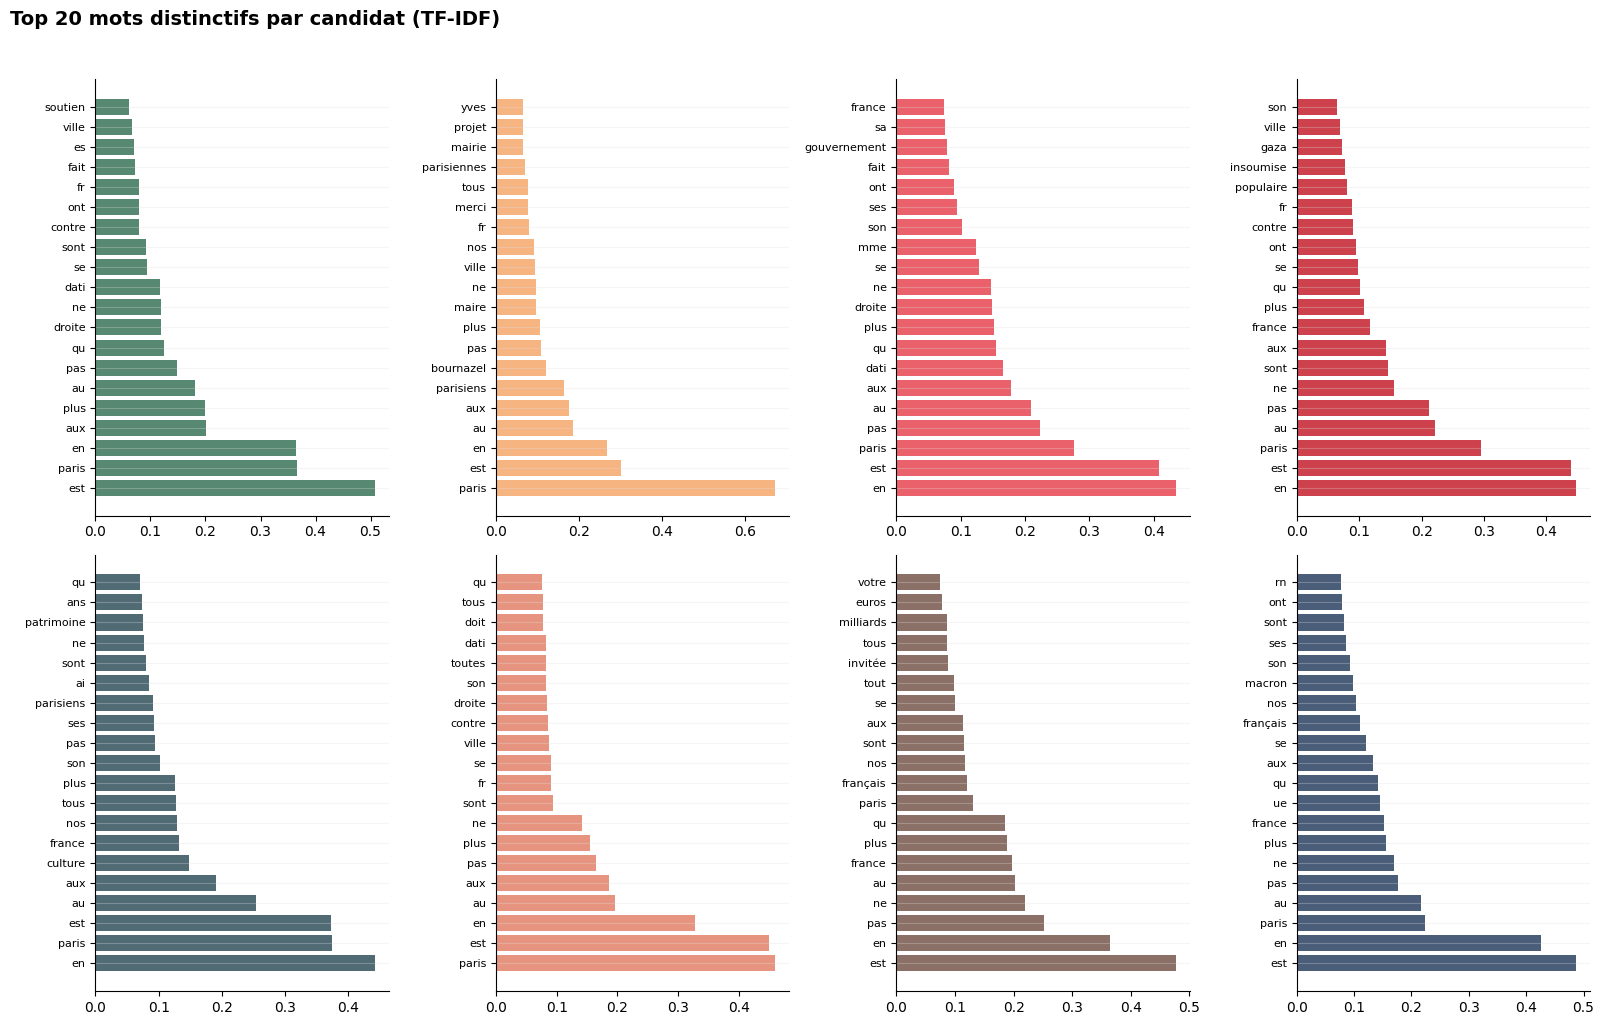

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

docs = tweets.groupby("candidate")["text_clean"].apply(lambda x: " ".join(x.dropna())).to_dict()
vectorizer = TfidfVectorizer(max_features=5000, min_df=2)
mat = vectorizer.fit_transform(list(docs.values()))
names = vectorizer.get_feature_names_out()
cands = list(docs.keys())

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()
for i, (ax, c) in enumerate(zip(axes, cands)):
    row = mat[i].toarray().flatten()
    idx = np.argsort(row)[-20:][::-1]
    mots = [names[j] for j in idx if row[j] > 0]
    vals = [row[j] for j in idx if row[j] > 0]
    if mots:
        y_pos = np.arange(len(mots))
        ax.barh(y_pos, vals, color=COLORS.get(c, "#333"), alpha=0.8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(mots, fontsize=8)
    ax.set_title(c, fontsize=11, fontweight="bold", loc="left")
    swiss_style(ax, "", None, None)
plt.suptitle("Top 20 mots distinctifs par candidat (TF-IDF)", fontsize=14, fontweight="bold", x=0, y=1.02, ha="left")
plt.tight_layout()
fig.savefig(FIG_DIR / "02_tfidf_signatures.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 2.3bis Comparaison lexicale par paire

Mots distinctifs en miroir : Brossat vs Knafo, Grégoire vs Dati. Chaque côté affiche les termes les plus typiques du candidat.

In [4]:
# Barplot miroir : Brossat vs Knafo, Grégoire vs Dati (TF-IDF déjà calculé)
cand_alias = {"Grégoire": "Gregoire", "Gregoire": "Gregoire"}
def barplot_miroir(mat, names, cands, c1, c2, ax, top=12):
    c1k = cand_alias.get(c1, c1)
    c2k = cand_alias.get(c2, c2)
    i1 = next((i for i, c in enumerate(cands) if c == c1 or c == c1k), None)
    i2 = next((i for i, c in enumerate(cands) if c == c2 or c == c2k), None)
    if i1 is None or i2 is None:
        return
    for idx, (i, c, color) in enumerate([(i1, c1, COLORS.get(c1, "#E63946")), (i2, c2, COLORS.get(c2, "#264653"))]):
        row = mat[i].toarray().flatten()
        top_idx = np.argsort(row)[-top:][::-1]
        mots = [names[j] for j in top_idx if row[j] > 0][:top]
        vals = [row[j] for j in top_idx if row[j] > 0][:top]
        if not mots:
            continue
        y = np.arange(len(mots))
        if idx == 0:
            ax.barh(y, vals, color=color, alpha=0.8, label=c, height=0.7)
        else:
            ax.barh(y, [-v for v in vals], color=color, alpha=0.8, label=c, height=0.7)
        ax.set_yticks(y)
        ax.set_yticklabels(mots, fontsize=9)
    ax.axvline(0, color="black", lw=0.8)
    ax.legend(loc="upper right", fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
barplot_miroir(mat, names, cands, "Brossat", "Knafo", axes[0])
swiss_style(axes[0], "Brossat vs Knafo (TF-IDF)", source="tweets_twitter.csv")
barplot_miroir(mat, names, cands, "Grégoire", "Dati", axes[1])
swiss_style(axes[1], "Grégoire vs Dati (TF-IDF)", source="tweets_twitter.csv")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_tfidf_miroir_paires.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### 2.3bis Comparaison lexicale par paire

Mots distinctifs de chaque camp : Brossat vs Knafo (gauche vs droite), Grégoire vs Dati (gauche modérée vs LR).

### 2.3bis Comparaison lexicale par paire

Mots distinctifs de chaque camp : Brossat vs Knafo (gauche vs droite), Grégoire vs Dati (gauche modérée vs LR).

## 2.4 Nuage de mots par camp

Cinq wordclouds : un par camp idéologique (extrême gauche, gauche, centre, droite, extrême droite). Regroupement des tweets par camp pour identifier les thématiques dominantes.

In [5]:
# Wordclouds par camp (5 camps)
from wordcloud import WordCloud

tweets["camp"] = tweets["candidate"].map(lambda c: next((k for k, v in CAMPS.items() if c in v or (c == "Gregoire" and "Grégoire" in v), "autre")))
by_camp = tweets[tweets["camp"] != "autre"].groupby("camp")["text_clean"].apply(lambda x: " ".join(x.dropna())).to_dict()
camp_colors = {"Extrême gauche": "#C1121F", "Gauche": "#2D6A4F", "Centre": "#F4A261", "Droite": "#264653", "Extrême droite": "#1D3557"}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i, (camp, txt) in enumerate(by_camp.items()):
    if i >= len(axes):
        break
    ax = axes[i]
    wc = WordCloud(max_words=50, background_color="white", width=400, height=300, colormap="viridis").generate(txt)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(camp, fontsize=11, fontweight="bold", loc="left")
    ax.axis("off")
    swiss_style(ax, "", None, None)
for j in range(len(by_camp), len(axes)):
    axes[j].axis("off")
fig.suptitle("Wordclouds par camp idéologique", fontsize=14, fontweight="bold", x=0, y=1.02, ha="left")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_wordclouds_camps.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

SyntaxError: invalid syntax (3165678439.py, line 4)

## 2.4 Topics par candidat

In [ ]:
if topics is not None and len(topics) > 0:
    cols = [c for c in topics.columns if c != "Unnamed: 0" and not c.startswith("Unnamed")]
    if not cols:
        cols = topics.columns[1:].tolist()
    topic_mat = topics.set_index(topics.columns[0])[cols].astype(float)
    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(topic_mat.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=25)
    ax.set_xticks(np.arange(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(np.arange(len(topic_mat.index)))
    ax.set_yticklabels(topic_mat.index)
    plt.colorbar(im, ax=ax, label="%")
    swiss_style(ax, "Répartition des thèmes par candidat (%)", None, "A2_matrix_candidat_topic")
    fig.savefig(FIG_DIR / "02_topics_heatmap.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

## 2.5 Analyse hashtags

Extraction des hashtags (texte + colonne), top 30 global, top 10 par candidat (grille 2×4), top 20 par ER médian.

In [ ]:
# Parser hashtags depuis text + colonne hashtags
def parse_hashtags(row):
    tags = []
    if pd.notna(row.get("hashtags")) and str(row["hashtags"]).strip():
        tags.extend(re.findall(r"#(\w+)", str(row["hashtags"])))
    if pd.notna(row.get("text")) and str(row["text"]):
        tags.extend(re.findall(r"#(\w+)", str(row["text"])))
    return list(set(t.lower() for t in tags))

tweets["hashtags_list"] = tweets.apply(parse_hashtags, axis=1)
all_ht = [h for L in tweets["hashtags_list"] for h in L]
top30 = Counter(all_ht).most_common(30)
print("Top 30 hashtags global:", [(h, c) for h, c in top30[:15]], "...")

# Top 10 par candidat (grille 2x4)
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()
for i, c in enumerate(tweets["candidate"].unique()[:8]):
    ht_c = Counter([h for L in tweets[tweets["candidate"] == c]["hashtags_list"] for h in L]).most_common(10)
    mots = [x[0] for x in ht_c]
    vals = [x[1] for x in ht_c]
    if mots:
        ax = axes[i]
        ax.barh(range(len(mots)), vals, color=COLORS.get(c, "#333"), alpha=0.8)
        ax.set_yticks(range(len(mots)))
        ax.set_yticklabels(mots, fontsize=8)
        ax.set_title(c, fontsize=10, fontweight="bold", loc="left")
        swiss_style(ax, "", None, None)
plt.suptitle("Top 10 hashtags par candidat", fontsize=14, fontweight="bold", x=0, y=1.02, ha="left")
plt.tight_layout()
fig.savefig(FIG_DIR / "02_hashtags_candidat.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 2.6 Hashtags engageants vs fréquents

Scatter fréquence × ER médian. Les hashtags en haut à droite sont à la fois fréquents et engageants ; en bas à gauche, peu utilisés et peu engageants. Annotation des extrêmes.

In [ ]:
# Scatter fréquence × ER médian par hashtag
ht_er = []
for _, row in tweets.iterrows():
    er = row.get("engagement_rate", 0) or 0
    for h in row["hashtags_list"]:
        ht_er.append((h, er))
ht_df = pd.DataFrame(ht_er, columns=["hashtag", "er"])
agg = ht_df.groupby("hashtag").agg(freq=("er", "count"), er_median=("er", "median")).reset_index()
agg = agg[agg["freq"] >= 3]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(agg["freq"], agg["er_median"], alpha=0.6, s=30, c="#264653")
top_er = agg.nlargest(5, "er_median")
top_freq = agg.nlargest(5, "freq")
for _, r in top_er.iterrows():
    ax.annotate(r["hashtag"], (r["freq"], r["er_median"]), fontsize=8, alpha=0.9)
for _, r in top_freq.iterrows():
    if r["hashtag"] not in top_er["hashtag"].values:
        ax.annotate(r["hashtag"], (r["freq"], r["er_median"]), fontsize=8, alpha=0.9)
ax.set_xlabel("Fréquence (nb tweets)")
ax.set_ylabel("ER médian")
swiss_style(ax, "2.6 Hashtags : fréquence × engagement", source="tweets_twitter.csv")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_hashtags_engageants.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 2.8 ER national vs municipal

Boxplot du taux d'engagement par catégorie d'orientation (national, municipal, mixte) et par candidat. Test Mann-Whitney pour comparer les distributions.

In [ ]:
# Boxplot ER par orientation (national/municipal/mixte)
from scipy.stats import mannwhitneyu
tw_er = tweets.copy()
tw_er["er_pct"] = tw_er["engagement_rate"].fillna(0) * 10
tw_ori = tw_er[tw_er["orientation"].isin(["national", "municipal", "mixte"])]

fig, ax = plt.subplots(figsize=(10, 5))
ord_cat = ["municipal", "mixte", "national"]
data = [tw_ori[tw_ori["orientation"] == c]["er_pct"].dropna() for c in ord_cat]
bp = ax.boxplot(data, labels=["Municipal", "Mixte", "National"], patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#f0f0f0")
swiss_style(ax, "2.8 ER (‰) par catégorie national/municipal", source="tweets_twitter.csv")
ax.set_ylabel("ER (‰)")

# Mann-Whitney national vs municipal
n_rec, m_rec = tw_ori[tw_ori["orientation"]=="national"]["er_pct"].dropna(), tw_ori[tw_ori["orientation"]=="municipal"]["er_pct"].dropna()
if len(n_rec) >= 5 and len(m_rec) >= 5:
    stat, pval = mannwhitneyu(n_rec, m_rec, alternative="two-sided")
    ax.text(0.02, 0.98, f"Mann-Whitney national vs municipal: p={pval:.4f}", transform=ax.transAxes, fontsize=9, va="top")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_er_national_municipal.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 2.10 Topics × engagement

ER médian par thème : quels topics génèrent le plus d'engagement ? Croisement candidat × topic via la matrice A2.

In [ ]:
# Barplot ER médian par topic (A2_topic_engagement_ranking)
topic_eng = _safe_read(A2_OUT / "A2_topic_engagement_ranking.csv")
if topic_eng is not None and len(topic_eng) > 0:
    topic_eng = topic_eng.dropna(subset=["topic_short", "med_eng_global"])
    topic_eng["topic_short"] = topic_eng["topic_short"].fillna(topic_eng["topic_name"])
    fig, ax = plt.subplots(figsize=(10, 5))
    ord_t = topic_eng.sort_values("med_eng_global", ascending=True)
    y_pos = np.arange(len(ord_t))
    ax.barh(y_pos, ord_t["med_eng_global"], color="#264653", alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ord_t["topic_short"], fontsize=9)
    ax.set_xlabel("ER médian (engagement)")
    swiss_style(ax, "2.10 ER médian par topic", source="A2_topic_engagement_ranking.csv")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "02_topics_engagement.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

## 2.6 Hashtags engageants vs fréquents

Scatter fréquence × ER médian. Les hashtags en haut à droite sont à la fois fréquents et engageants ; en bas à gauche, peu utilisés et peu engageants. Annotation des extrêmes.

In [ ]:
# Scatter fréquence × ER médian par hashtag
ht_er = []
for _, row in tweets.iterrows():
    er = row.get("engagement_rate", 0) or 0
    for h in row["hashtags_list"]:
        ht_er.append((h, er))
ht_df = pd.DataFrame(ht_er, columns=["hashtag", "er"])
agg = ht_df.groupby("hashtag").agg(freq=("er", "count"), er_median=("er", "median")).reset_index()
agg = agg[agg["freq"] >= 3]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(agg["freq"], agg["er_median"], alpha=0.6, s=30, c="#264653")
top_er = agg.nlargest(5, "er_median")
top_freq = agg.nlargest(5, "freq")
for _, r in top_er.iterrows():
    ax.annotate(r["hashtag"], (r["freq"], r["er_median"]), fontsize=8, alpha=0.9)
for _, r in top_freq.iterrows():
    if r["hashtag"] not in top_er["hashtag"].values:
        ax.annotate(r["hashtag"], (r["freq"], r["er_median"]), fontsize=8, alpha=0.9)
ax.set_xlabel("Fréquence (nb tweets)")
ax.set_ylabel("ER médian")
swiss_style(ax, "2.6 Hashtags : fréquence × engagement", source="tweets_twitter.csv")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_hashtags_engageants.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 2.5 National vs municipal

In [ ]:
MUNI = "paris arrondissement mairie métro logement hidalgo quartier parisien vélib propreté crèche école urbanisme transport piste cyclable conseil".split()
NAT = "france français macron gouvernement immigration assemblée européen europe sénat président nation république retraite pension loi réforme zemmour mélenchon bardella".split()

def classer_orientation(txt):
    if not txt or pd.isna(txt):
        return "neutre"
    t = str(txt).lower()
    nm, nn = sum(1 for m in MUNI if m in t), sum(1 for m in NAT if m in t)
    if nm >= 2 and nn < 2:
        return "municipal"
    if nn >= 2 and nm < 2:
        return "national"
    if nm >= 1 and nn >= 1:
        return "mixte"
    return "neutre"

tweets["orientation"] = tweets["text_clean"].apply(classer_orientation)
ori = tweets.groupby(["candidate", "orientation"]).size().unstack(fill_value=0)
ori_pct = ori.div(ori.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))
bottom = np.zeros(len(ori_pct))
colors_ori = {"municipal": "#2D6A4F", "national": "#E63946", "mixte": "#F4A261", "neutre": "#999"}
for col in ["municipal", "national", "mixte", "neutre"]:
    if col in ori_pct.columns:
        ax.barh(ori_pct.index, ori_pct[col], left=bottom, label=col, color=colors_ori.get(col, "#999"), height=0.6)
        bottom += ori_pct[col].values
ax.legend(loc="upper right", fontsize=9)
swiss_style(ax, "National vs municipal par candidat (%)", "Mots-clés: paris, mairie, logement vs macron, immigration, gouvernement", "tweets_twitter")
ax.set_xlabel("%")
fig.savefig(FIG_DIR / "02_national_municipal.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 2.6 Synthèse

In [ ]:
display(ori_pct.round(1))

Brossat place 20 % de son contenu sur le thème Anti-droite/Dati, Dati 15,6 % sur le logement, Mariani 17 % sur la géopolitique. Les signatures TF-IDF distinguent nettement chaque candidat. La part national/municipal varie selon le positionnement : Knafo et Mariani plus tournés vers le national, Grégoire et Belliard vers le municipal.